# 01 - Preparación del Dataset en PyTorch

## 1. Imports y configuración

In [20]:
from pathlib import Path
import os
import sys
import random
import json
import zipfile
import subprocess
from collections import defaultdict
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [21]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    DATA_DIR = Path("/content/data")
else:
    DATA_DIR = Path("../data")

RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Entorno Colab:", IS_COLAB)
print("DATA_DIR:", DATA_DIR)


## 1.b Instalación opcional de dependencias

Instala dependencias si el notebook corre en Google Colab.

In [ ]:
if IS_COLAB:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "pandas",
        "numpy",
        "matplotlib",
        "pillow",
        "torch",
        "torchvision",
        "tqdm",
        "jupyter",
        "kaggle",
        "gdown",
    ])
else:
    print("Instalación opcional omitida: usá tu entorno local con requirements.txt")


## 2. Descarga / ubicación del dataset

Detecta el dataset local y, si no existe, lo descarga y extrae automáticamente.

In [22]:
CARDD_ZIP_URL = "https://drive.usercontent.google.com/download?id=1bbyqVCKZX5Ur5Zg-uKj0jD0maWAVeOLx&export=download&authuser=0"
CARDD_FILE_ID = "1bbyqVCKZX5Ur5Zg-uKj0jD0maWAVeOLx"
ZIP_PATH = DATA_DIR / "CarDD_release.zip"
EXTRACT_DIR = DATA_DIR

def ensure_gdown():
    try:
        import gdown
        return gdown
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "gdown"])
        import gdown
        return gdown


def download_cardd_zip(url=CARDD_ZIP_URL, file_id=CARDD_FILE_ID, zip_path=ZIP_PATH):
    if zip_path.exists() and zipfile.is_zipfile(zip_path):
        print(f"ZIP válido ya descargado en: {zip_path}")
        return zip_path

    if zip_path.exists() and not zipfile.is_zipfile(zip_path):
        print("El archivo descargado existente no es un ZIP válido. Se volverá a descargar.")
        zip_path.unlink()

    print("Descargando CarDD...")
    try:
        urlretrieve(url, zip_path)
    except Exception as error:
        print(f"Descarga directa falló: {error}")

    if zip_path.exists() and zipfile.is_zipfile(zip_path):
        print(f"Descarga completada: {zip_path}")
        return zip_path

    print("La descarga directa no produjo un ZIP válido. Intentando con gdown...")
    if zip_path.exists():
        zip_path.unlink()

    gdown = ensure_gdown()
    gdown.download(id=file_id, output=str(zip_path), quiet=False)

    if not zipfile.is_zipfile(zip_path):
        raise zipfile.BadZipFile("La descarga final no produjo un archivo ZIP válido.")

    print(f"Descarga completada con gdown: {zip_path}")
    return zip_path


def extract_cardd_zip(zip_path=ZIP_PATH, extract_dir=EXTRACT_DIR):
    if not zip_path.exists():
        raise FileNotFoundError(f"No existe el ZIP en {zip_path}")

    if not zipfile.is_zipfile(zip_path):
        raise zipfile.BadZipFile(f"{zip_path} no es un ZIP válido")

    print(f"Extrayendo {zip_path} en {extract_dir}...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extracción completada.")


def find_dataset_root():
    dataset_candidates = [
        RAW_DIR / "CarDD",
        DATA_DIR / "CarDD",
        DATA_DIR / "CarDD_release",
        DATA_DIR / "CarDD_release" / "CarDD_COCO",
        DATA_DIR / "CarDD" / "CarDD_COCO",
    ]
    return next((path for path in dataset_candidates if path.exists()), None), dataset_candidates

dataset_root, dataset_candidates = find_dataset_root()

if dataset_root is None:
    print("Dataset no encontrado. Intentando descargar y extraer automáticamente...")
    download_cardd_zip()
    extract_cardd_zip()
    dataset_root, dataset_candidates = find_dataset_root()

if dataset_root is None:
    raise FileNotFoundError(
        "No se encontró el dataset incluso después de intentar descargarlo automáticamente.\n"
        + "Rutas verificadas:\n"
        + "\n".join(str(path) for path in dataset_candidates)
    )

print("Dataset encontrado en:", dataset_root)


Dataset encontrado en: ../data/CarDD_release


## 3. Exploración de estructura de carpetas

Muestra la estructura del dataset y cuenta las imágenes disponibles.

In [23]:
for path in sorted(dataset_root.iterdir()):
    print(path)


../data/CarDD_release/CarDD_COCO
../data/CarDD_release/CarDD_SOD


In [24]:
image_paths = [
    path for path in dataset_root.rglob("*")
    if path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Cantidad de imágenes encontradas:", len(image_paths))


Cantidad de imágenes encontradas: 16000


## 4. Construcción del dataframe a partir de anotaciones COCO oficiales

Convierte las anotaciones COCO en un DataFrame con ruta, etiqueta y split.

In [25]:
if (dataset_root / "CarDD_COCO").exists():
    coco_root = dataset_root / "CarDD_COCO"
else:
    coco_root = dataset_root

annotation_dir = coco_root / "annotations"

annotation_files = {
    "train": annotation_dir / "instances_train2017.json",
    "val": annotation_dir / "instances_val2017.json",
    "test": annotation_dir / "instances_test2017.json",
}

missing_files = [str(path) for path in annotation_files.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Faltan archivos de anotaciones COCO:\n"
        + "\n".join(missing_files)
    )

all_images = {
    path.name: path
    for path in coco_root.rglob("*")
    if path.suffix.lower() in IMAGE_EXTENSIONS
}

rows = []

for split, annotation_path in annotation_files.items():
    data = json.loads(annotation_path.read_text(encoding="utf-8"))

    category_map = {
        category["id"]: category["name"]
        for category in data["categories"]
    }
    image_map = {
        image["id"]: image.get("file_name")
        for image in data["images"]
    }
    labels_by_image = defaultdict(list)

    for ann in data["annotations"]:
        image_id = ann.get("image_id")
        category_id = ann.get("category_id")

        if image_id in image_map and category_id in category_map:
            labels_by_image[image_id].append(category_map[category_id])

    for image_id, filename in image_map.items():
        if not filename or filename not in all_images:
            continue

        labels = sorted(set(labels_by_image.get(image_id, [])))
        if not labels:
            continue

        image_label = labels[0] if len(labels) == 1 else "multiple_damage"

        rows.append({
            "image_path": str(all_images[filename].relative_to(DATA_DIR)),
            "label": image_label,
            "split": split,
        })

df = pd.DataFrame(rows).drop_duplicates(subset=["image_path"])

if df.empty:
    raise ValueError("El dataframe quedó vacío después de leer las anotaciones COCO.")

print(df.head())
print("\nColumnas disponibles:", df.columns.tolist())
print("Total de imágenes:", len(df))
print(df["label"].value_counts())
print("\nDistribución por split oficial:")
print(df["split"].value_counts())


                                      image_path            label  split
0  CarDD_release/CarDD_COCO/train2017/000001.jpg  multiple_damage  train
1  CarDD_release/CarDD_COCO/train2017/000002.jpg        tire flat  train
2  CarDD_release/CarDD_COCO/train2017/000003.jpg        tire flat  train
3  CarDD_release/CarDD_COCO/train2017/000004.jpg        tire flat  train
4  CarDD_release/CarDD_COCO/train2017/000005.jpg        tire flat  train

Columnas disponibles: ['image_path', 'label', 'split']
Total de imágenes: 4000
label
multiple_damage    1530
scratch             963
glass shatter       557
dent                518
tire flat           239
lamp broken         104
crack                89
Name: count, dtype: int64

Distribución por split oficial:
split
train    2816
val       810
test      374
Name: count, dtype: int64


## Distribución de clases

In [26]:
class_counts = df["label"].value_counts()
class_counts


label
multiple_damage    1530
scratch             963
glass shatter       557
dent                518
tire flat           239
lamp broken         104
crack                89
Name: count, dtype: int64

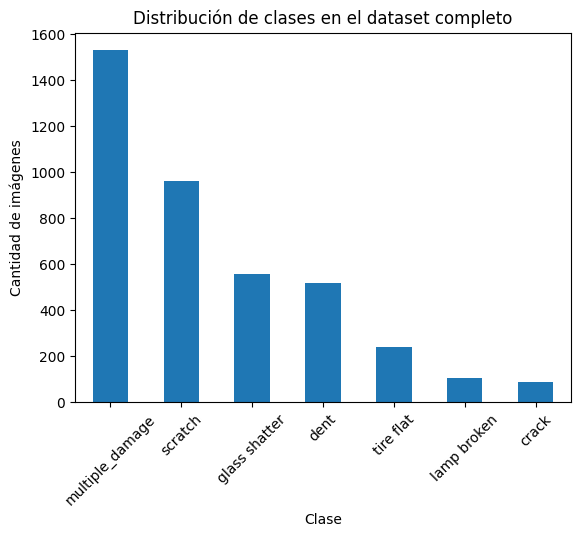

In [27]:
class_counts.plot(kind="bar")
plt.title("Distribución de clases en el dataset completo")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=45)
plt.show()


## 5. Uso de splits oficiales train / val / test

Se reutilizan los splits oficiales del dataset y se separan en train, val y test.

In [28]:
if "split" not in df.columns:
    raise ValueError(
        "La columna 'split' no existe en df. Seguramente quedó cargada una versión vieja del dataframe. "
        "Hacé Kernel -> Restart y luego Run All para reconstruir df con el parser actualizado."
    )

train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
    raise ValueError("No se pudieron recuperar correctamente los splits oficiales desde las anotaciones.")


Train: 2816
Val: 810
Test: 374


## 6. Guardado de CSVs

In [29]:
train_df = train_df[["image_path", "label"]].reset_index(drop=True)
val_df = val_df[["image_path", "label"]].reset_index(drop=True)
test_df = test_df[["image_path", "label"]].reset_index(drop=True)

train_df.to_csv(DATA_DIR / "train.csv", index=False)
val_df.to_csv(DATA_DIR / "val.csv", index=False)
test_df.to_csv(DATA_DIR / "test.csv", index=False)

print("CSVs guardados en:", DATA_DIR.resolve())
print("Los CSVs respetan los splits oficiales del dataset.")


CSVs guardados en: /home/joaquin/code/proyecto_final_redes/data
Los CSVs respetan los splits oficiales del dataset.


In [30]:
dist_table = pd.DataFrame({
    "total": df["label"].value_counts(),
    "train": train_df["label"].value_counts(),
    "val": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts()
}).fillna(0).astype(int)

dist_table


,total,train,val,test
label,,,,
multiple_damage,1530,1084,306,140
scratch,963,683,197,83
glass shatter,557,391,110,56
dent,518,359,106,53
tire flat,239,172,42,25
lamp broken,104,69,25,10
crack,89,58,24,7


## 7. Clase Dataset de PyTorch

Implementa una clase `Dataset` para cargar imágenes y etiquetas desde los CSVs.

In [31]:
class CarDamageDataset(Dataset):
    def __init__(self, csv_path, data_dir, class_to_idx=None, transform=None):
        self.data = pd.read_csv(csv_path)
        self.data_dir = Path(data_dir)
        self.transform = transform

        if class_to_idx is None:
            classes = sorted(self.data["label"].unique())
            self.class_to_idx = {
                class_name: idx
                for idx, class_name in enumerate(classes)
            }
        else:
            self.class_to_idx = class_to_idx

        self.idx_to_class = {
            idx: class_name
            for class_name, idx in self.class_to_idx.items()
        }

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        image_path = self.data_dir / row["image_path"]
        label_name = row["label"]
        label = self.class_to_idx[label_name]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [32]:
classes = sorted(train_df["label"].unique())
class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}
idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

class_to_idx


{'crack': 0,
 'dent': 1,
 'glass shatter': 2,
 'lamp broken': 3,
 'multiple_damage': 4,
 'scratch': 5,
 'tire flat': 6}

## 8. Transforms y normalización

Redimensiona, convierte a tensor y normaliza las imágenes para el modelo.

In [33]:
IMG_SIZE = 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


- Train usa augmentation y validación/test usan solo preprocesamiento.

## 9. DataLoaders

Crea los DataLoaders de train, val y test con la configuración correspondiente.

In [34]:
BATCH_SIZE = 32

train_dataset = CarDamageDataset(
    csv_path=DATA_DIR / "train.csv",
    data_dir=DATA_DIR,
    class_to_idx=class_to_idx,
    transform=train_transform
)

val_dataset = CarDamageDataset(
    csv_path=DATA_DIR / "val.csv",
    data_dir=DATA_DIR,
    class_to_idx=class_to_idx,
    transform=eval_transform
)

test_dataset = CarDamageDataset(
    csv_path=DATA_DIR / "test.csv",
    data_dir=DATA_DIR,
    class_to_idx=class_to_idx,
    transform=eval_transform
)


In [35]:
num_workers = 2 if os.cpu_count() and os.cpu_count() > 1 else 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers
)

print(f"num_workers usados: {num_workers}")


num_workers usados: 2


## 10. Visualización de augmentations

Muestra ejemplos de augmentations aplicadas sobre imágenes de entrenamiento.

In [36]:
def denormalize(tensor, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return tensor * std + mean


def show_augmentations(dataset, index, n=6):
    if len(dataset) == 0:
        print("El dataset está vacío.")
        return

    index = min(index, len(dataset) - 1)
    original_row = dataset.data.iloc[index]
    image_path = dataset.data_dir / original_row["image_path"]
    label = original_row["label"]

    image = Image.open(image_path).convert("RGB")

    fig, axes = plt.subplots(1, n, figsize=(15, 4))
    if n == 1:
        axes = [axes]

    for i in range(n):
        augmented = train_transform(image)
        augmented = denormalize(augmented, imagenet_mean, imagenet_std)
        augmented = augmented.clamp(0, 1)

        axes[i].imshow(augmented.permute(1, 2, 0))
        axes[i].axis("off")
        axes[i].set_title(label)

    plt.suptitle("Ejemplos de data augmentation")
    plt.show()


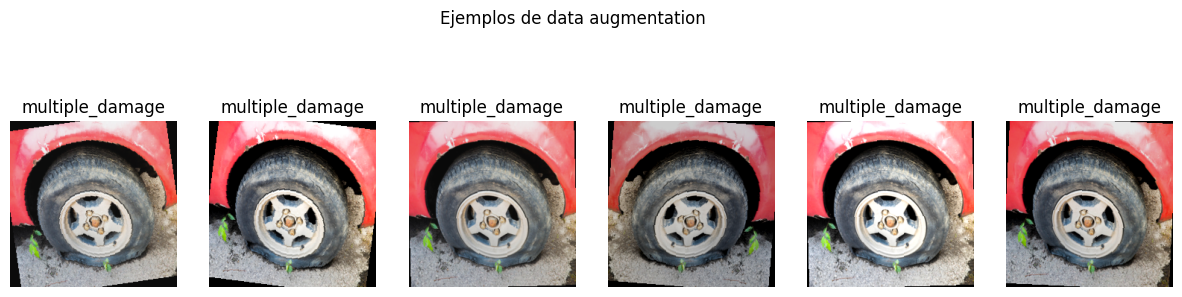

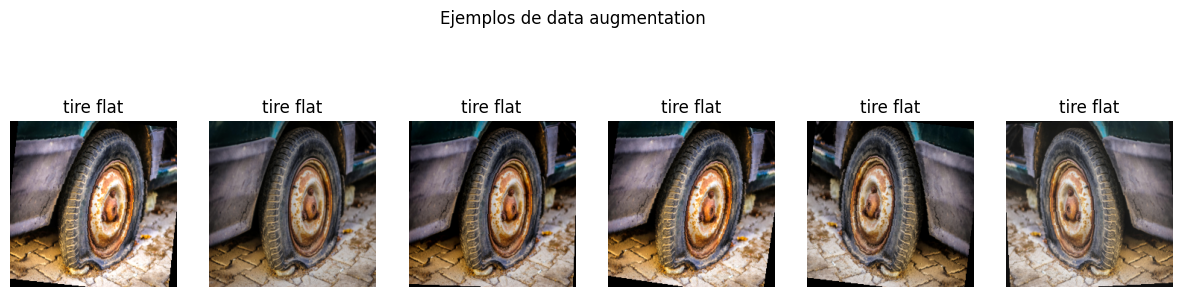

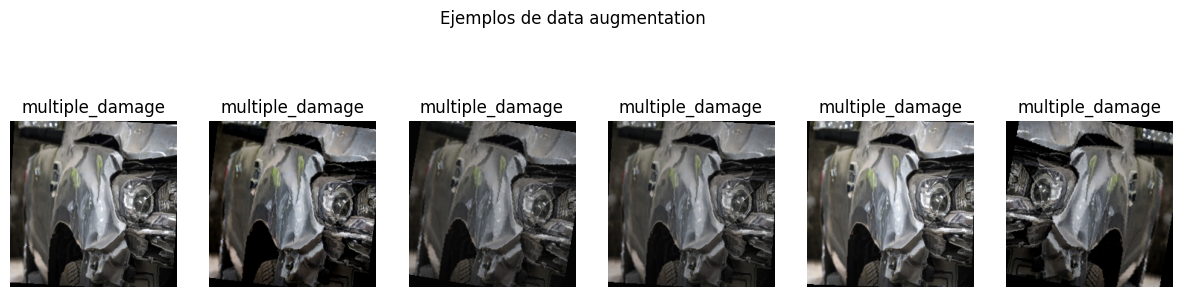

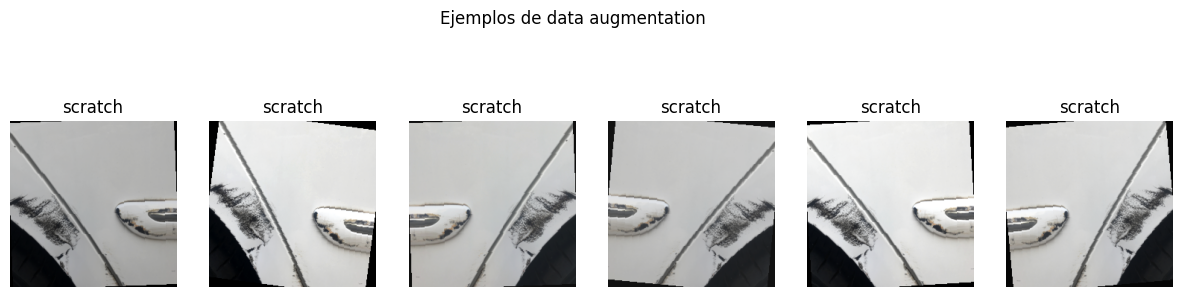

In [37]:
candidate_indices = [0, 10, 20, 30]
valid_indices = [idx for idx in candidate_indices if idx < len(train_dataset)]

for idx in valid_indices:
    show_augmentations(train_dataset, index=idx, n=6)

if not valid_indices:
    print("No hay suficientes imágenes para mostrar augmentations.")


## 11. Verificación final de batches

Verifica shapes, rango de valores y visualización final de un batch.

In [38]:
images, labels = next(iter(train_loader))

print("Shape del batch de imágenes:", images.shape)
print("Shape del batch de etiquetas:", labels.shape)
print("Valor mínimo luego de normalización:", images.min().item())
print("Valor máximo luego de normalización:", images.max().item())


Shape del batch de imágenes: torch.Size([32, 3, 224, 224])
Shape del batch de etiquetas: torch.Size([32])
Valor mínimo luego de normalización: -2.1179039478302
Valor máximo luego de normalización: 2.640000104904175


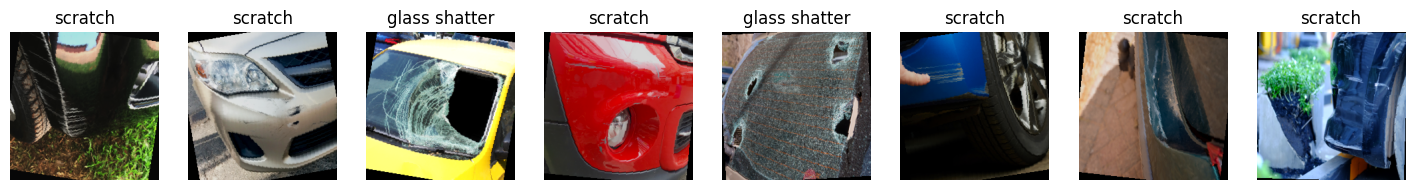

In [39]:
def show_batch(images, labels, idx_to_class, n=8):
    n = min(n, len(images))
    images = images[:n]
    labels = labels[:n]

    fig, axes = plt.subplots(1, n, figsize=(18, 4))
    if n == 1:
        axes = [axes]

    for i in range(n):
        img = denormalize(images[i], imagenet_mean, imagenet_std)
        img = img.clamp(0, 1)

        label_idx = labels[i].item()
        label_name = idx_to_class[label_idx]

        axes[i].imshow(img.permute(1, 2, 0))
        axes[i].axis("off")
        axes[i].set_title(label_name)

    plt.show()

show_batch(images, labels, idx_to_class, n=8)
